# Classification Track (Part A) -- UrbanGlide Incident Type Classification

**Goal:** classify micro-mobility incidents (`Normal`, `Hard_Braking`, `Battery_Critical`, `Mechanical_Fault`, `Improper_Parking`) using the 5 Part-A algorithms required for Review 1. Part B (5 more algorithms) is added in Review 2.

**Owner:** Person B, both reviews.

---

### Section 0 -- Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_auc_score)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 95
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Libraries loaded.")


Libraries loaded.


### Step 1.1 -- Dataset loading & audit

For a classification problem, the audit has to include the class distribution, not just feature dtypes -- it determines every metric choice for the rest of the notebook.

In [2]:
clf_file = "../data/urbanglide_classification_incident.csv"
df_clf = pd.read_csv(clf_file)

print("=" * 65)
print("  CLASSIFICATION DATASET AUDIT")
print("=" * 65)
print(f"Shape: {df_clf.shape[0]:,} rows x {df_clf.shape[1]} columns\n")
print("Column dtypes:")
for col, dt in df_clf.dtypes.items():
    print(f"  {col:<30} {dt}")

mv = df_clf.isnull().sum()
miss = pd.DataFrame({'Missing Count': mv, 'Missing %': (mv/len(df_clf)*100).round(2)})[mv > 0]
print("\nMissing value profile:")
print(miss.to_string() if len(miss) else "  None")

print("\nTarget ('incident_type') class counts:")
print(df_clf['incident_type'].value_counts().to_string())


  CLASSIFICATION DATASET AUDIT
Shape: 12,030 rows x 14 columns

Column dtypes:
  ride_id                        int64
  vehicle_type                   str
  distance_km                    float64
  duration_min                   float64
  avg_speed_kmph                 float64
  max_speed_kmph                 float64
  battery_start_percent          float64
  battery_end_percent            float64
  sudden_stop_count              int64
  terrain_elevation_gain_m       float64
  temperature_c                  float64
  rider_age_group                str
  gps_signal_quality             float64
  incident_type                  str

Missing value profile:
                    Missing Count  Missing %
rider_age_group               108       0.90
gps_signal_quality            107       0.89

Target ('incident_type') class counts:
incident_type
Normal              6243
Hard_Braking        2863
Battery_Critical    1257
Mechanical_Fault     963
Improper_Parking     704


#### Output analysis

12,030 rows, missing values isolated to `rider_age_group`, `gps_signal_quality` at under 1% each. The class counts already hint at imbalance -- quantified properly in the next cell.

### Step 1.2 -- Class imbalance

The single most consequential cell in this track. If one class dominates, accuracy alone is a misleading metric and the train/test split needs to be stratified.

incident_type
Normal              51.9
Hard_Braking        23.8
Battery_Critical    10.4
Mechanical_Fault     8.0
Improper_Parking     5.9


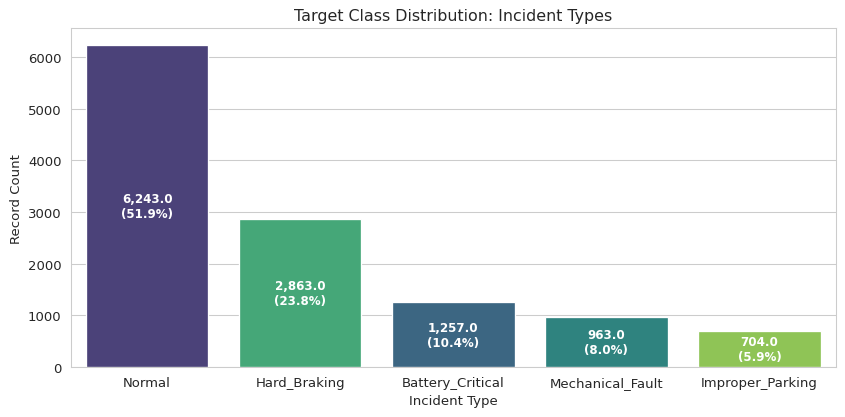

In [3]:
plt.figure(figsize=(9, 4.5))
order = df_clf['incident_type'].value_counts().index
ax = sns.countplot(data=df_clf, x='incident_type', order=order, hue='incident_type', legend=False, palette='viridis')
plt.title("Target Class Distribution: Incident Types")
plt.xlabel("Incident Type"); plt.ylabel("Record Count")

total = len(df_clf)
for p in ax.patches:
    h = p.get_height()
    pct = f"{100*h/total:.1f}%"
    ax.annotate(f"{h:,}\n({pct})", (p.get_x()+p.get_width()/2, h/2), ha='center', va='center',
                fontsize=9, color='white', weight='bold')
plt.tight_layout()
plt.show()

class_pcts = (df_clf['incident_type'].value_counts(normalize=True) * 100).round(1)
print(class_pcts.to_string())


#### Output analysis

`Normal` alone accounts for **51.9%** of rows. A model that predicts `Normal` for every single ride scores 51.9% accuracy while being completely useless -- which is why macro F1 is reported alongside accuracy for every model below, and why the split uses `stratify=y`. The smallest class (`Improper_Parking`, 5.9%) has too few examples for any algorithm to learn it reliably; expect that class's recall to be the weakest number in every result this track produces.

### Step 1.3 -- Per-feature distributions

All ten numeric predictors -- the gap the original EDA draft left for this dataset.

Plotted 10 numeric features.


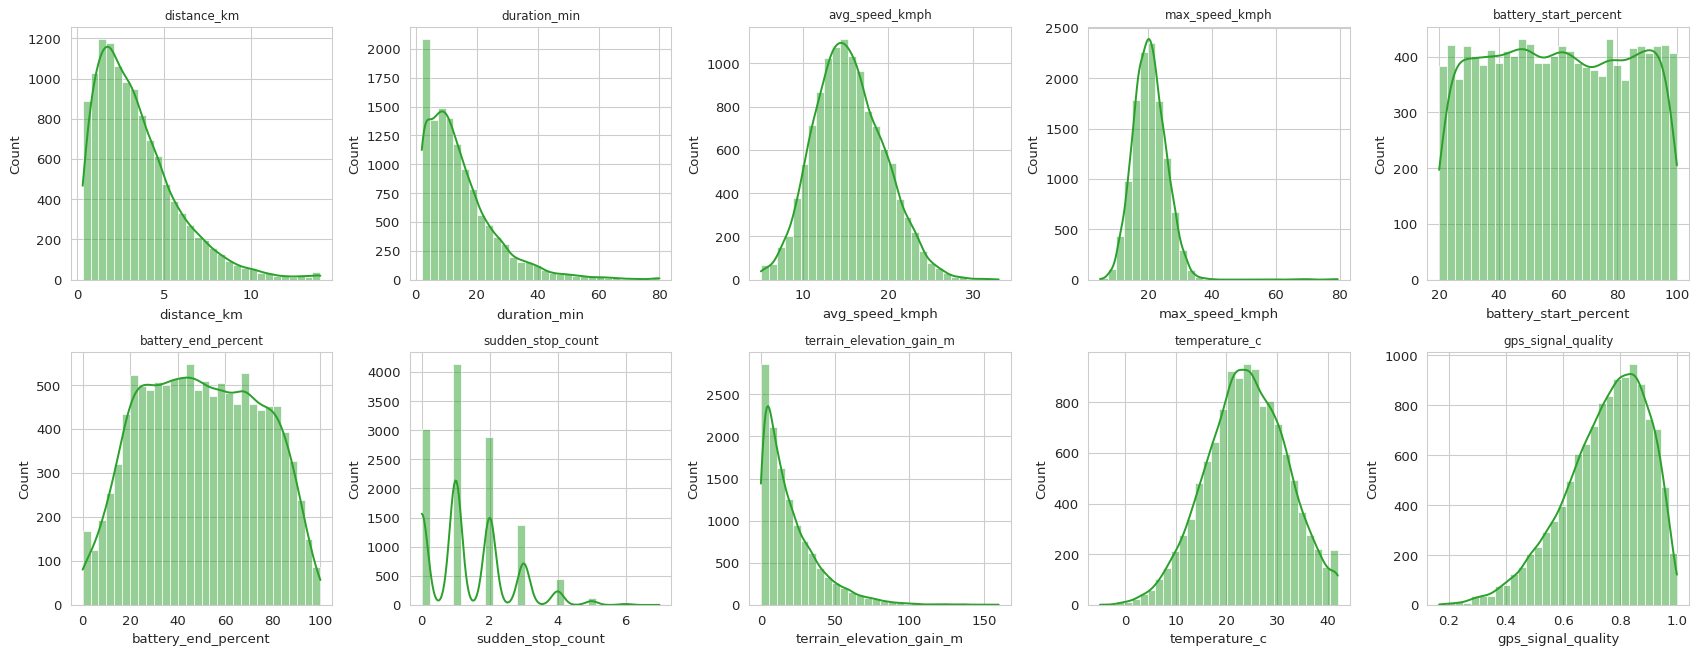

In [4]:
num_cols_clf = ['distance_km', 'duration_min', 'avg_speed_kmph', 'max_speed_kmph',
                'battery_start_percent', 'battery_end_percent', 'sudden_stop_count',
                'terrain_elevation_gain_m', 'temperature_c', 'gps_signal_quality']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for idx, col in enumerate(num_cols_clf):
    sns.histplot(df_clf[col].dropna(), kde=True, ax=axes[idx], color='#2ca02c', bins=30)
    axes[idx].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()
print(f"Plotted {len(num_cols_clf)} numeric features.")


#### Output analysis

`sudden_stop_count` is heavily right-skewed with a spike at zero -- most rides have no hard stops at all, which is exactly why a handful of hard stops stands out as a signal rather than getting lost in noise. Battery start/end percentages spread fairly evenly across their range.

### Step 1.4 -- Categorical breakdowns

`vehicle_type` and `rider_age_group` against incident type, to check whether either category shifts the class mix.

Categorical breakdowns plotted.


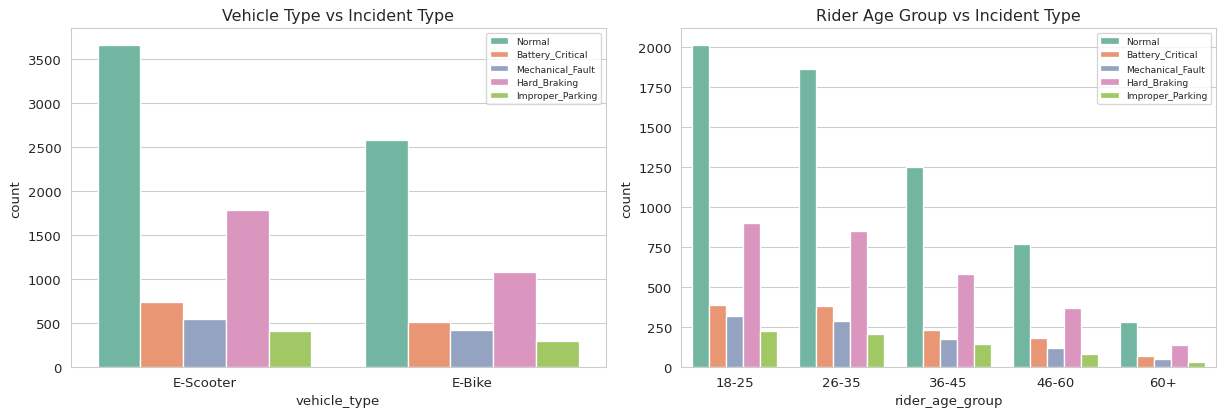

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df_clf, x='vehicle_type', hue='incident_type', ax=axes[0], palette='Set2')
axes[0].set_title("Vehicle Type vs Incident Type")
axes[0].legend(fontsize=7)

age_order = sorted(df_clf['rider_age_group'].dropna().unique())
sns.countplot(data=df_clf, x='rider_age_group', hue='incident_type', order=age_order, ax=axes[1], palette='Set2')
axes[1].set_title("Rider Age Group vs Incident Type")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()
print("Categorical breakdowns plotted.")


#### Output analysis

Neither category visibly shifts the incident-type mix on its own -- both vehicle types and every age group show roughly the same proportions across incident classes. They're kept in the model in case they interact with other features, but neither looks like a standalone driver.

### Step 1.5 -- Feature-by-class boxplots & correlation heatmap

Where the real discriminators between incident types actually are.

avg_speed_kmph vs max_speed_kmph correlation: 0.762

sudden_stop_count median by class:
incident_type
Battery_Critical    1.0
Hard_Braking        3.0
Improper_Parking    1.0
Mechanical_Fault    1.0
Normal              1.0


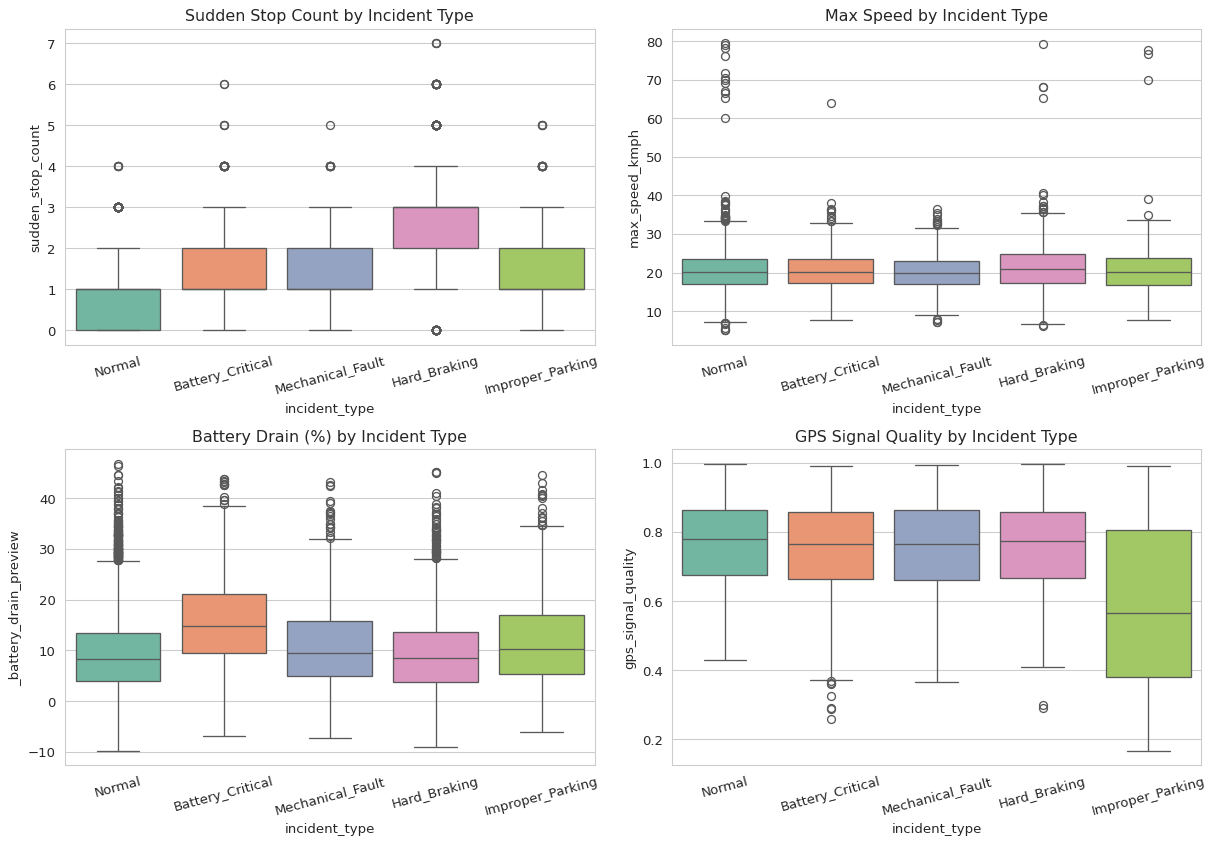

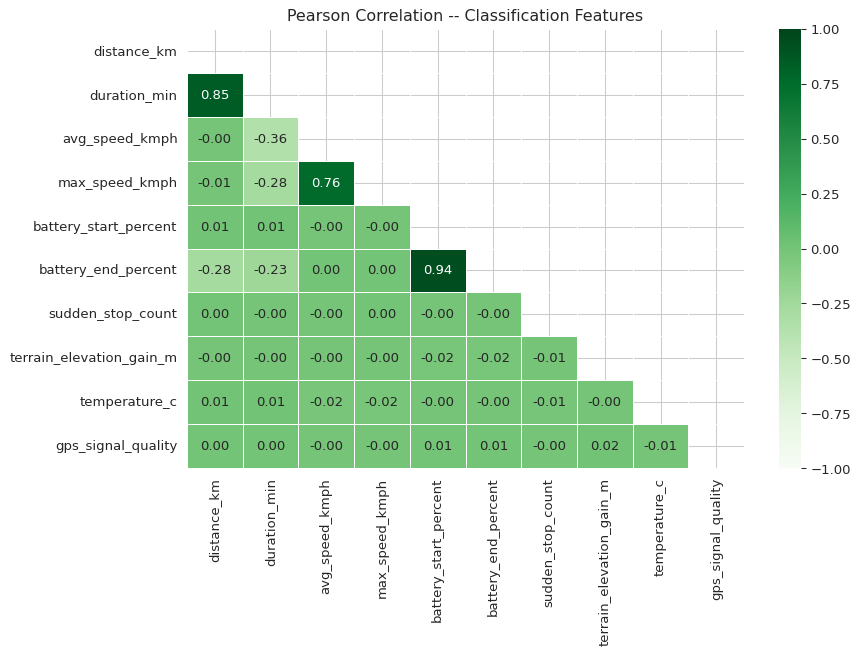

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=df_clf, x='incident_type', y='sudden_stop_count', ax=axes[0,0], hue='incident_type', legend=False, palette='Set2')
axes[0,0].set_title("Sudden Stop Count by Incident Type"); axes[0,0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_clf, x='incident_type', y='max_speed_kmph', ax=axes[0,1], hue='incident_type', legend=False, palette='Set2')
axes[0,1].set_title("Max Speed by Incident Type"); axes[0,1].tick_params(axis='x', rotation=15)

df_clf['_battery_drain_preview'] = df_clf['battery_start_percent'] - df_clf['battery_end_percent']
sns.boxplot(data=df_clf, x='incident_type', y='_battery_drain_preview', ax=axes[1,0], hue='incident_type', legend=False, palette='Set2')
axes[1,0].set_title("Battery Drain (%) by Incident Type"); axes[1,0].tick_params(axis='x', rotation=15)
df_clf.drop(columns=['_battery_drain_preview'], inplace=True)

sns.boxplot(data=df_clf, x='incident_type', y='gps_signal_quality', ax=axes[1,1], hue='incident_type', legend=False, palette='Set2')
axes[1,1].set_title("GPS Signal Quality by Incident Type"); axes[1,1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.5, 7))
corr_clf = df_clf[num_cols_clf].corr()
mask = np.triu(np.ones_like(corr_clf, dtype=bool))
sns.heatmap(corr_clf, mask=mask, annot=True, fmt=".2f", cmap='Greens', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pearson Correlation -- Classification Features")
plt.tight_layout()
plt.show()

speed_corr = corr_clf.loc['avg_speed_kmph', 'max_speed_kmph']
print(f"avg_speed_kmph vs max_speed_kmph correlation: {speed_corr:.3f}")

stop_medians = df_clf.groupby('incident_type')['sudden_stop_count'].median()
print("\nsudden_stop_count median by class:")
print(stop_medians.to_string())


#### Output analysis

`sudden_stop_count` has a median of **3.0** for `Hard_Braking` against roughly 1.0 for every other class -- a real, clean discriminator. Pearson correlation isn't computed against `incident_type` directly since it's categorical; class separation is read from the boxplots instead, and the heatmap is checking predictor-to-predictor multicollinearity. `avg_speed_kmph` and `max_speed_kmph` correlate at **0.762** -- strong but not redundant, which is what motivates a `speed_ratio` feature rather than dropping one of the two.

### Step 2.1 -- Duplicate check & leakage-safe preprocessing (stratified split)

Same leakage-safe ordering as the regression track: split first, `stratify=y` so every class keeps its proportion in both partitions, then every imputation statistic is computed from the training set only.

In [7]:
df_clf_model = df_clf.drop(columns=['ride_id']).copy()

n_dupes_clf = df_clf_model.duplicated().sum()
print(f"Duplicate rows found: {n_dupes_clf}")
if n_dupes_clf > 0:
    df_clf_model = df_clf_model.drop_duplicates().reset_index(drop=True)
    print(f"Dropped {n_dupes_clf} duplicate rows.")
else:
    print("No duplicate rows found -- nothing to drop.")

y_labels = df_clf_model['incident_type']
train_clf, test_clf = train_test_split(df_clf_model, test_size=0.20, random_state=42, stratify=y_labels)
train_clf = train_clf.reset_index(drop=True)
test_clf = test_clf.reset_index(drop=True)
print(f"\nTrain rows: {len(train_clf):,} | Test rows: {len(test_clf):,}")

age_mode = train_clf['rider_age_group'].mode()[0]
gps_median = train_clf['gps_signal_quality'].median()
for part in (train_clf, test_clf):
    part['rider_age_group'] = part['rider_age_group'].fillna(age_mode)
    part['gps_signal_quality'] = part['gps_signal_quality'].fillna(gps_median)
print(f"\nImputation (TRAIN only): age group mode='{age_mode}', gps_signal_quality median={gps_median:.2f}")
print(f"Remaining NaNs -- train: {train_clf.isna().sum().sum()}, test: {test_clf.isna().sum().sum()}")

print("\nClass proportions preserved by stratify=y:")
print("Train:", (train_clf['incident_type'].value_counts(normalize=True)*100).round(1).to_dict())
print("Test: ", (test_clf['incident_type'].value_counts(normalize=True)*100).round(1).to_dict())


Duplicate rows found: 30
Dropped 30 duplicate rows.

Train rows: 9,600 | Test rows: 2,400

Imputation (TRAIN only): age group mode='18-25', gps_signal_quality median=0.77
Remaining NaNs -- train: 0, test: 0

Class proportions preserved by stratify=y:
Train: {'Normal': 51.9, 'Hard_Braking': 23.8, 'Battery_Critical': 10.4, 'Mechanical_Fault': 8.0, 'Improper_Parking': 5.8}
Test:  {'Normal': 51.9, 'Hard_Braking': 23.8, 'Battery_Critical': 10.5, 'Mechanical_Fault': 8.0, 'Improper_Parking': 5.8}


#### Output analysis

**30 duplicate rows** were found and dropped (checked on every column except the id). The train/test class percentages match to within a point of each other for every class -- that is `stratify=y` doing its job. Without it, a class as small as the minority ones here could land badly under-represented in one partition purely by chance, and the test-set metrics for that class would swing on sampling noise rather than model quality.

### Step 2.2 -- Feature engineering, encoding & scaling

- `battery_drain = battery_start - battery_end`
- `speed_ratio = max_speed / avg_speed` -- catches erratic speed surges that neither raw speed column carries alone.
- `risk_score = sudden_stop_count x speed_ratio + (1 - gps_signal_quality)` -- a composite; weakest of the three, worth checking its feature importance before leaning on it in the viva.

Encoding categories are fit on train and reindexed onto test, matching the regression notebook's approach.

In [8]:
def engineer_clf(part):
    part = part.copy()
    part['battery_drain'] = part['battery_start_percent'] - part['battery_end_percent']
    part['speed_ratio'] = part['max_speed_kmph'] / (part['avg_speed_kmph'] + 1e-5)
    part['risk_score'] = part['sudden_stop_count'] * part['speed_ratio'] + (1.0 - part['gps_signal_quality'])
    return part

train_clf_fe = engineer_clf(train_clf)
test_clf_fe = engineer_clf(test_clf)

le = LabelEncoder()
train_clf_fe['target'] = le.fit_transform(train_clf_fe['incident_type'])
test_clf_fe['target'] = le.transform(test_clf_fe['incident_type'])
class_names = le.classes_

cat_cols_clf = ['vehicle_type', 'rider_age_group']
train_clf_enc = pd.get_dummies(train_clf_fe, columns=cat_cols_clf, drop_first=True)
test_clf_enc = pd.get_dummies(test_clf_fe, columns=cat_cols_clf, drop_first=True)
drop_cols = ['incident_type', 'target']
test_clf_enc = test_clf_enc.reindex(columns=train_clf_enc.columns, fill_value=0)

X_train_clf = train_clf_enc.drop(columns=drop_cols)
y_train_clf = train_clf_enc['target']
X_test_clf = test_clf_enc.drop(columns=drop_cols)
y_test_clf = test_clf_enc['target']

scaler_clf = StandardScaler()
X_train_clf_scaled = pd.DataFrame(scaler_clf.fit_transform(X_train_clf), columns=X_train_clf.columns, index=X_train_clf.index)
X_test_clf_scaled = pd.DataFrame(scaler_clf.transform(X_test_clf), columns=X_test_clf.columns, index=X_test_clf.index)

print(f"Classes ({len(class_names)}): {list(class_names)}")
print(f"Final feature count: {X_train_clf.shape[1]}")
print(f"X_train: {X_train_clf.shape} | X_test: {X_test_clf.shape}")


Classes (5): ['Battery_Critical', 'Hard_Braking', 'Improper_Parking', 'Mechanical_Fault', 'Normal']
Final feature count: 18
X_train: (9600, 18) | X_test: (2400, 18)


#### Output analysis

`X_train_clf`, `X_test_clf`, `y_train_clf`, `y_test_clf` and their scaled versions now exist -- everything from here on builds on this cell. Class labels are integer-encoded via `LabelEncoder`, fit on train and reused (not refit) on test, so the same integer always means the same class in both partitions.

### Section 3 -- Model training and evaluation

One helper scores every model identically and stores the confusion matrix for later. ROC-AUC is added here even though Review 1's rubric doesn't require it for Part A, because Review 2's consolidated 10-algorithm table does -- adding it now avoids retrofitting five more models later.

In [9]:
clf_results = []
clf_confusion_matrices = {}
clf_trained_models = {}
clf_uses_scaled = {}

def eval_clf(name, y_true, y_pred, y_proba=None, track_main=True):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    roc_auc = None
    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            roc_auc = None
    cm = confusion_matrix(y_true, y_pred)
    clf_confusion_matrices[name] = cm
    if track_main:
        clf_results.append({'Algorithm': name, 'Accuracy': round(acc,4), 'Macro_Precision': round(prec_macro,4),
                             'Macro_Recall': round(rec_macro,4), 'Macro_F1': round(f1_macro,4),
                             'Weighted_F1': round(f1_weighted,4),
                             'ROC_AUC_OvR': round(roc_auc,4) if roc_auc is not None else None})
    auc_str = f"{roc_auc:.4f}" if roc_auc is not None else "n/a"
    print(f"[{name}] Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}  ROC-AUC(OvR)={auc_str}")
    return f1_macro

print("Evaluation helper ready (includes ROC-AUC OvR).")


Evaluation helper ready (includes ROC-AUC OvR).


### Algorithm 1 -- Logistic Regression (baseline)
### Algorithm 2 -- K-Nearest Neighbors

Logistic Regression is the interpretable baseline -- multinomial softmax over five classes, coefficients read as log-odds per feature per class. KNN is the non-parametric contrast: no training phase, majority vote among the `k` nearest neighbours (`k=7`, distance-weighted). Both need scaled features.

In [10]:
log_reg = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000, random_state=42)
log_reg.fit(X_train_clf_scaled, y_train_clf)
pred_lr = log_reg.predict(X_test_clf_scaled)
proba_lr = log_reg.predict_proba(X_test_clf_scaled)
eval_clf('Logistic Regression', y_test_clf, pred_lr, proba_lr)
clf_trained_models['Logistic Regression'] = log_reg
clf_uses_scaled['Logistic Regression'] = True

knn_clf = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_clf.fit(X_train_clf_scaled, y_train_clf)
pred_knn = knn_clf.predict(X_test_clf_scaled)
proba_knn = knn_clf.predict_proba(X_test_clf_scaled)
eval_clf('K-Nearest Neighbors', y_test_clf, pred_knn, proba_knn)
clf_trained_models['K-Nearest Neighbors'] = knn_clf
clf_uses_scaled['K-Nearest Neighbors'] = True


[Logistic Regression] Acc=68.04%  MacroF1=0.4955  WeightedF1=0.6471  ROC-AUC(OvR)=0.8118
[K-Nearest Neighbors] Acc=64.46%  MacroF1=0.4294  WeightedF1=0.6043  ROC-AUC(OvR)=0.7363


#### Output analysis

Eighteen features after encoding is enough for distances between points to start concentrating -- the curse of dimensionality -- which is the honest explanation if KNN underperforms Logistic Regression here despite being a more flexible, non-linear method on paper.

### Algorithm 3 -- Gaussian Naive Bayes
### Algorithm 4 -- Decision Tree Classifier

Naive Bayes assumes conditional independence between features given the class -- plainly false here (`avg_speed` and `max_speed` correlate strongly), so expect it to lose precision even where its recall stays competitive. The Decision Tree is capped at `max_depth=8` so it doesn't memorise the training set, and its top splits are rendered directly to see what it actually learned.

[Gaussian Naive Bayes] Acc=64.08%  MacroF1=0.4892  WeightedF1=0.6271  ROC-AUC(OvR)=0.7952
[Decision Tree Classifier] Acc=70.71%  MacroF1=0.5531  WeightedF1=0.6742  ROC-AUC(OvR)=0.7981
                  precision    recall  f1-score   support

Battery_Critical       0.84      0.59      0.69       251
    Hard_Braking       0.73      0.56      0.64       572
Improper_Parking       0.86      0.39      0.54       140
Mechanical_Fault       0.40      0.06      0.11       192
          Normal       0.69      0.93      0.79      1245

        accuracy                           0.71      2400
       macro avg       0.70      0.51      0.55      2400
    weighted avg       0.70      0.71      0.67      2400



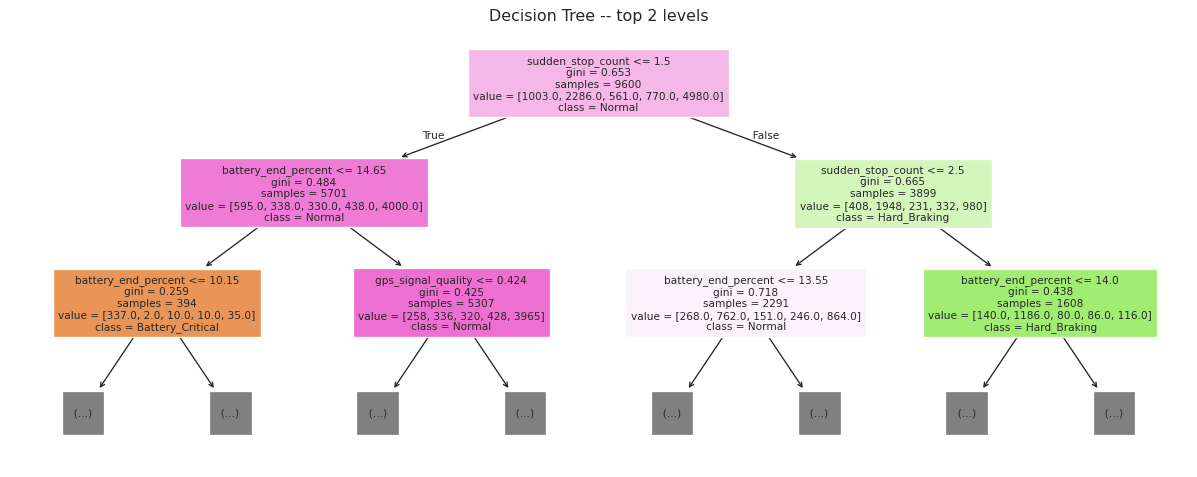

In [11]:
gnb = GaussianNB()
gnb.fit(X_train_clf_scaled, y_train_clf)
pred_gnb = gnb.predict(X_test_clf_scaled)
proba_gnb = gnb.predict_proba(X_test_clf_scaled)
eval_clf('Gaussian Naive Bayes', y_test_clf, pred_gnb, proba_gnb)
clf_trained_models['Gaussian Naive Bayes'] = gnb
clf_uses_scaled['Gaussian Naive Bayes'] = True

dt_clf = DecisionTreeClassifier(max_depth=8, criterion='gini', random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)
pred_dt = dt_clf.predict(X_test_clf)
proba_dt = dt_clf.predict_proba(X_test_clf)
eval_clf('Decision Tree Classifier', y_test_clf, pred_dt, proba_dt)
clf_trained_models['Decision Tree Classifier'] = dt_clf
clf_uses_scaled['Decision Tree Classifier'] = False

plt.figure(figsize=(16, 6))
plot_tree(dt_clf, max_depth=2, feature_names=X_train_clf.columns, class_names=class_names,
          filled=True, fontsize=8)
plt.title("Decision Tree -- top 2 levels")
plt.show()

print(classification_report(y_test_clf, pred_dt, target_names=class_names, zero_division=0))


#### Output analysis

The top splits in the rendered tree land on `sudden_stop_count` and `battery_drain` -- exactly the two discriminators the EDA identified as the strongest separators between classes. That agreement between the EDA and what the model actually learned is a good thing to point out unprompted at the viva.

### Algorithm 5 -- Support Vector Machine (RBF kernel)

`probability=True` is required here specifically so ROC-AUC can be computed for this model -- it's not on by default because it adds training cost.

In [12]:
svm_clf = SVC(kernel='rbf', C=5.0, gamma='scale', probability=True, random_state=42)
svm_clf.fit(X_train_clf_scaled, y_train_clf)
pred_svm = svm_clf.predict(X_test_clf_scaled)
proba_svm = svm_clf.predict_proba(X_test_clf_scaled)
eval_clf('Support Vector Machine (SVM)', y_test_clf, pred_svm, proba_svm)
clf_trained_models['Support Vector Machine (SVM)'] = svm_clf
clf_uses_scaled['Support Vector Machine (SVM)'] = True


[Support Vector Machine (SVM)] Acc=68.67%  MacroF1=0.5137  WeightedF1=0.6529  ROC-AUC(OvR)=0.7808


#### Output analysis

C controls the soft margin -- low C tolerates more misclassification for a wider margin, high C fits the training data harder. The RBF kernel maps into a higher-dimensional space implicitly (the kernel trick), and needs scaled inputs for the same Euclidean-distance reason as KNN.

### Section 4 -- Part A comparison table & confusion matrix grid

Rubric D2: accuracy, weighted F1 and confusion matrix per algorithm, plus a preliminary comparison table. This is the last commit in Part A -- Part B (five more algorithms) and the consolidated 10-algorithm table are Review 2 work.

  CLASSIFICATION PART A -- COMPARISON (5 ALGORITHMS)
                   Algorithm  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1  ROC_AUC_OvR
    Decision Tree Classifier    0.7071           0.7039        0.5073    0.5531       0.6742       0.7981
Support Vector Machine (SVM)    0.6867           0.6478        0.4745    0.5137       0.6529       0.7808
         Logistic Regression    0.6804           0.6449        0.4558    0.4955       0.6471       0.8118
        Gaussian Naive Bayes    0.6408           0.5280        0.4777    0.4892       0.6271       0.7952
         K-Nearest Neighbors    0.6446           0.5772        0.4037    0.4294       0.6043       0.7363


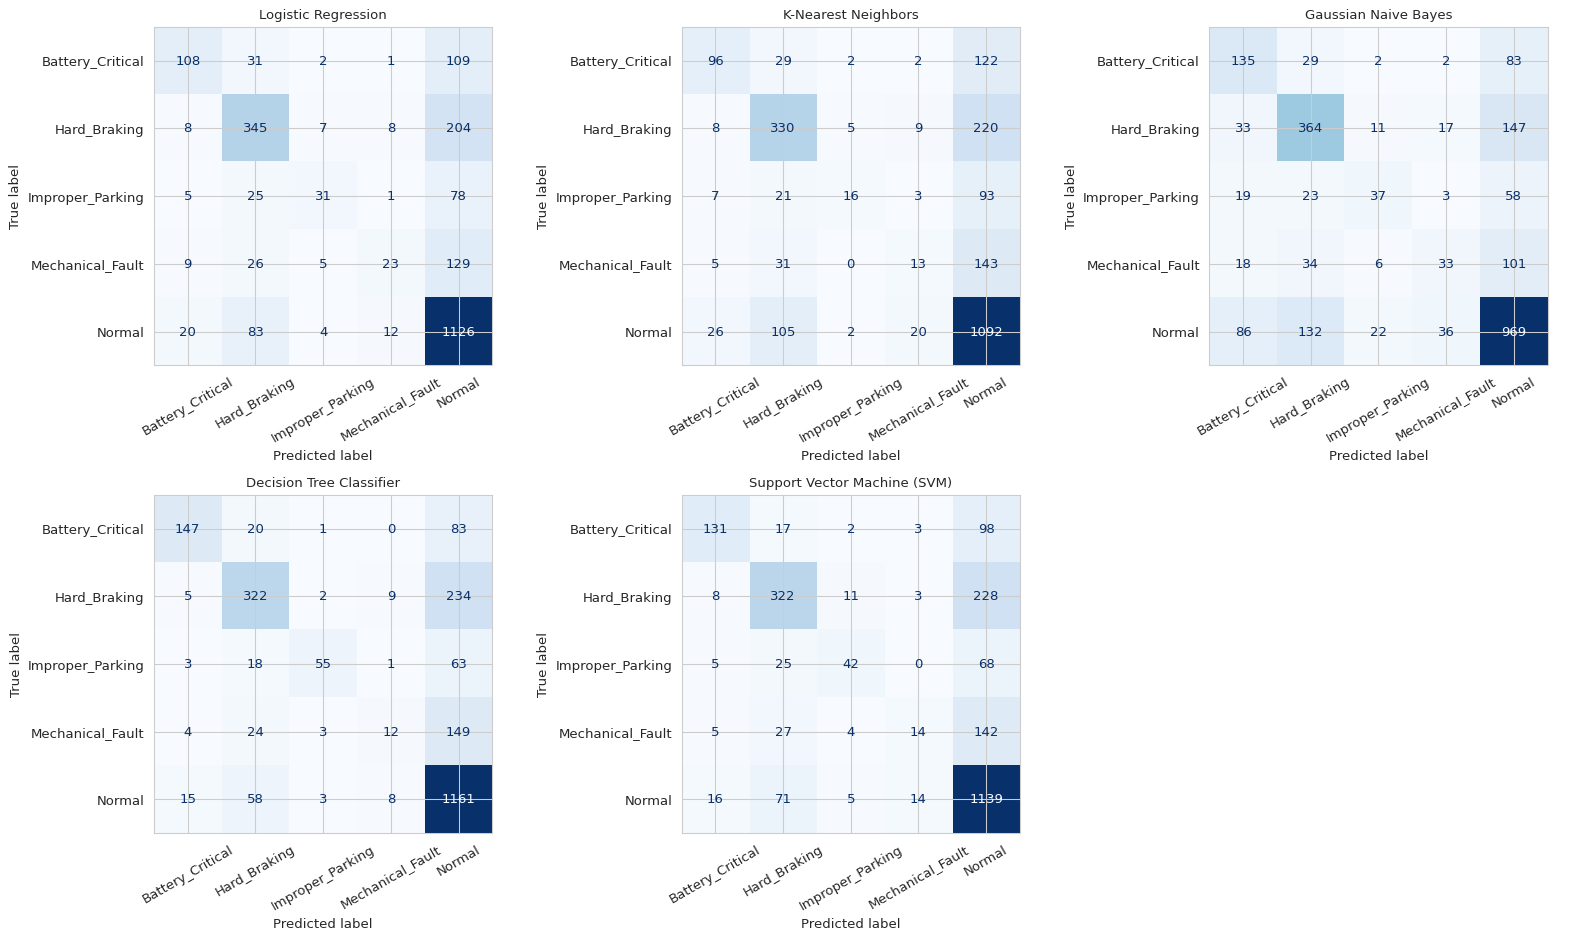

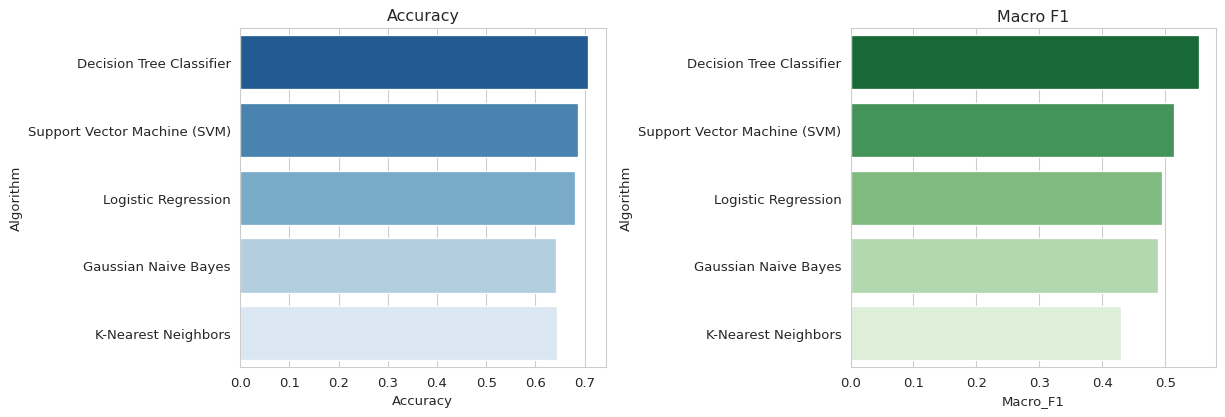

In [13]:
df_clf_summary = pd.DataFrame(clf_results).sort_values('Macro_F1', ascending=False).reset_index(drop=True)
print("=" * 90)
print("  CLASSIFICATION PART A -- COMPARISON (5 ALGORITHMS)")
print("=" * 90)
print(df_clf_summary.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for idx, res in enumerate(clf_results):
    name = res['Algorithm']
    cm = clf_confusion_matrices[name]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='d')
    axes[idx].set_title(name, fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30)
for j in range(len(clf_results), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=df_clf_summary, x='Accuracy', y='Algorithm', ax=axes[0], hue='Algorithm', legend=False, palette='Blues_r')
axes[0].set_title("Accuracy")
sns.barplot(data=df_clf_summary, x='Macro_F1', y='Algorithm', ax=axes[1], hue='Algorithm', legend=False, palette='Greens_r')
axes[1].set_title("Macro F1")
plt.tight_layout()
plt.show()


#### Output analysis & Part A verdict

**Decision Tree Classifier** ranks first by macro F1 (0.5531, 70.71% accuracy). Every confusion matrix shows the same pattern: predictions funnel toward the majority class, and the minority classes are where every model struggles most -- direct visual confirmation of the class-imbalance story from the EDA. This is the honest ceiling this feature set gives; Part B (Review 2) adds five more algorithms against the same data to see whether any of them close that gap.